In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import glob, os
dataset_path = "/content/drive/MyDrive/rgb"
image_files = sorted(glob.glob(os.path.join(dataset_path, "*.png")))
print("Total images:", len(image_files))

Total images: 613


In [3]:
!pip install kornia kornia_moons -q

import torch
import kornia as K
import kornia.feature as KF
import cv2
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

device = 'cuda' if torch.cuda.is_available() else 'cpu'

disk = KF.DISK.from_pretrained('depth').to(device).eval()
lg_matcher = KF.LightGlueMatcher('disk').to(device).eval()

print("DISK + LightGlue loaded on", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 89.5 MB/s eta 0:00:00
Downloading: "https://raw.githubusercontent.com/cvlab-epfl/disk/master/depth-save.pth" to /root/.cache/torch/hub/checkpoints/depth-save.pth


100%|██████████| 4.17M/4.17M [00:00<00:00, 275MB/s]


Downloading: "https://github.com/cvg/LightGlue/releases/download/v0.1_arxiv/disk_lightglue.pth" to /root/.cache/torch/hub/checkpoints/disk_lightglue_v0-1_arxiv-pth


100%|██████████| 45.4M/45.4M [00:00<00:00, 138MB/s]

Loaded LightGlue model
DISK + LightGlue loaded on cuda


In [4]:
results_disk = []

for i in range(len(image_files) - 1):
    img1_bgr = cv2.imread(image_files[i])
    img2_bgr = cv2.imread(image_files[i + 1])
    img1_rgb = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2RGB)
    img2_rgb = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2RGB)

    t1 = K.image_to_tensor(img1_rgb, False).float().to(device) / 255.0
    t2 = K.image_to_tensor(img2_rgb, False).float().to(device) / 255.0

    with torch.no_grad():
        feats1 = disk(t1, n=2048, window_size=5, score_threshold=0.0, pad_if_not_divisible=True)[0]
        feats2 = disk(t2, n=2048, window_size=5, score_threshold=0.0, pad_if_not_divisible=True)[0]
        kpts1, desc1 = feats1.keypoints, feats1.descriptors
        kpts2, desc2 = feats2.keypoints, feats2.descriptors
        dists, idxs = lg_matcher(desc1, desc2, KF.laf_from_center_scale_ori(kpts1[None]),
                                  KF.laf_from_center_scale_ori(kpts2[None]))

    num_matches = len(idxs)
    if num_matches < 4:
        results_disk.append((i, i + 1, num_matches, 0))
        continue

    mkpts1 = kpts1[idxs[:, 0]].cpu().numpy()
    mkpts2 = kpts2[idxs[:, 1]].cpu().numpy()
    H, mask = cv2.findHomography(mkpts1, mkpts2, cv2.RANSAC, 5.0)
    inliers = int(mask.ravel().sum()) if mask is not None else 0
    results_disk.append((i, i + 1, num_matches, inliers))

    if i % 50 == 0:
        print(f"{i}/{len(image_files)-1} pairs done — matches={num_matches}, inliers={inliers}")

print("Finished all pairs:", len(results_disk))

/tmp/ipykernel_1476/2527030742.py:9: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  t1 = K.image_to_tensor(img1_rgb, False).float().to(device) / 255.0
/tmp/ipykernel_1476/2527030742.py:10: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  t2 = K.image_to_tensor(img2_rgb, False).float().to(device) / 255.0
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


0/612 pairs done — matches=1413, inliers=1402


/tmp/ipykernel_1476/2527030742.py:9: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  t1 = K.image_to_tensor(img1_rgb, False).float().to(device) / 255.0
/tmp/ipykernel_1476/2527030742.py:10: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  t2 = K.image_to_tensor(img2_rgb, False).float().to(device) / 255.0
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipykernel_1476/2527030742.py:9: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  t1 = K.image_to_tensor(img1_rgb, False).float().to(device) / 255.0
/tm

50/612 pairs done — matches=1501, inliers=1495


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipykernel_1476/2527030742.py:9: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  t1 = K.image_to_tensor(img1_rgb, False).float().to(device) / 255.0
/tmp/ipykernel_1476/2527030742.py:10: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  t2 = K.image_to_tensor(img2_rgb, False).float().to(device) / 255.0
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes

...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipykernel_1476/2527030742.py:9: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  t1 = K.image_to_tensor(img1_rgb, False).float().to(device) / 255.0
/tmp/ipykernel_1476/2527030742.py:10: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  t2 = K.image_to_tensor(img2_rgb, False).float().to(device) / 255.0
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes

600/612 pairs done — matches=1656, inliers=1654


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipykernel_1476/2527030742.py:9: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  t1 = K.image_to_tensor(img1_rgb, False).float().to(device) / 255.0
/tmp/ipykernel_1476/2527030742.py:10: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  t2 = K.image_to_tensor(img2_rgb, False).float().to(device) / 255.0
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes

Finished all pairs: 612


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
df_disk = pd.DataFrame(results_disk, columns=["Frame_n", "Frame_n+1", "Matches", "Inliers"])
df_disk["Inlier_Ratio"] = df_disk["Inliers"] / df_disk["Matches"].replace(0, pd.NA)

print("Rows:", len(df_disk))
print("Avg matches:", df_disk["Matches"].mean())
print("Avg inliers:", df_disk["Inliers"].mean())
print("Avg inlier ratio:", df_disk["Inlier_Ratio"].mean())

df_disk.to_csv("/content/drive/MyDrive/disk_lightglue_consecutive_pairs.csv", index=False)
print("Saved", len(df_disk), "rows to Drive")

Rows: 612
Avg matches: 1482.673202614379
Avg inliers: 1456.1568627450981
Avg inlier ratio: 0.9805360167877544


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Saved 612 rows to Drive


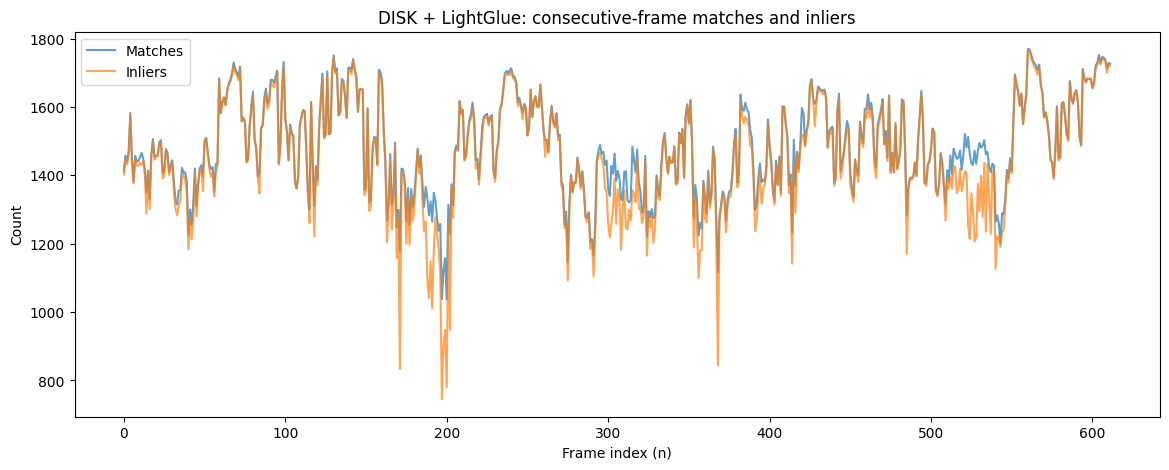

In [6]:
import matplotlib.pyplot as plt
from IPython.display import Image

plt.figure(figsize=(14, 5))
plt.plot(df_disk["Frame_n"], df_disk["Matches"], label="Matches", alpha=0.7)
plt.plot(df_disk["Frame_n"], df_disk["Inliers"], label="Inliers", alpha=0.7)
plt.xlabel("Frame index (n)")
plt.ylabel("Count")
plt.title("DISK + LightGlue: consecutive-frame matches and inliers")
plt.legend()
plt.savefig("/content/disk_plot.png", dpi=100, bbox_inches='tight')
plt.close()

Image("/content/disk_plot.png")

In [7]:
disk_counts = []
for i in range(0, len(image_files), 10):
    img_bgr = cv2.imread(image_files[i])
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    t = K.image_to_tensor(img_rgb, False).float().to(device) / 255.0
    with torch.no_grad():
        feats = disk(t, n=2048, window_size=5, score_threshold=0.0, pad_if_not_divisible=True)[0]
    disk_counts.append(len(feats.keypoints))

print("Avg DISK keypoints (sampled):", sum(disk_counts)/len(disk_counts))

/tmp/ipykernel_1476/2152271538.py:5: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  t = K.image_to_tensor(img_rgb, False).float().to(device) / 255.0
/tmp/ipykernel_1476/2152271538.py:5: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  t = K.image_to_tensor(img_rgb, False).float().to(device) / 255.0
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipykernel_1476/2152271538.py:5: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  t = K.image_to_tensor(img_rgb, False).float().to(device) / 255.0
/tmp/ipyke

Avg DISK keypoints (sampled): 2041.4516129032259


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipykernel_1476/2152271538.py:5: DeprecationWarning: Since kornia 0.8.3 the `image_to_tensor` is deprecated in favor of `kornia.image.image_to_tensor`.
  t = K.image_to_tensor(img_rgb, False).float().to(device) / 255.0
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [8]:
# Create DataFrame
df_disk = pd.DataFrame(
    results_disk,
    columns=["Frame_n", "Frame_n+1", "Matches", "Inliers"]
)

# Calculate Inlier Ratio
df_disk["Inlier_Ratio"] = (
    df_disk["Inliers"] /
    df_disk["Matches"].replace(0, pd.NA)
)

# Display first 10 rows
print(df_disk.head(10))

# Display statistics
print("\nSummary Statistics")
print("------------------")
print("Total Rows          :", len(df_disk))
print("Average Matches     :", df_disk["Matches"].mean())
print("Average Inliers     :", df_disk["Inliers"].mean())
print("Average Inlier Ratio:", df_disk["Inlier_Ratio"].mean())

# Save DataFrame to Google Drive
output_path = "/content/drive/MyDrive/disk_lightglue_consecutive_pairs.csv"
df_disk.to_csv(output_path, index=False)

print(f"\nSaved {len(df_disk)} rows to:")
print(output_path)

   Frame_n  Frame_n+1  Matches  Inliers  Inlier_Ratio
0        0          1     1413     1402      0.992215
1        1          2     1458     1447      0.992455
2        2          3     1441     1432      0.993754
3        3          4     1470     1464      0.995918
4        4          5     1582     1577      0.996839
5        5          6     1450     1441      0.993793
6        6          7     1381     1376      0.996379
7        7          8     1457     1446      0.992450
8        8          9     1440     1429      0.992361
9        9         10     1442     1428      0.990291

Summary Statistics
------------------
Total Rows          : 612
Average Matches     : 1482.673202614379
Average Inliers     : 1456.1568627450981
Average Inlier Ratio: 0.9805360167877544

Saved 612 rows to:
/content/drive/MyDrive/disk_lightglue_consecutive_pairs.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [13]:
print("cv2" in dir())
print("torch" in dir())
print("os" in dir())
try:
    print("dataset_dir:", dataset_dir)
except:
    print("dataset_dir not set")

True
True
True
dataset_dir not set


In [14]:
dataset_dir = '/content/drive/MyDrive/rgb'  # adjust if this account uses a different path, e.g. 'Dataset Rgb and mine/rgb'
robustness_dir = '/content/drive/MyDrive/assignment-3-dataset-low-texture-finding'  # adjust to wherever your 6 images actually are on this account

print(os.path.exists(dataset_dir))
print(os.path.exists(robustness_dir))

True
True


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from kornia.feature import match_smnn

def load_tensor_full(path, max_dim=1280):
    img_bgr = cv2.imread(path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]
    scale = max_dim / max(h, w)
    if scale < 1:
        img_rgb = cv2.resize(img_rgb, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_AREA)
    tensor = torch.from_numpy(img_rgb).permute(2, 0, 1).float().unsqueeze(0) / 255.0
    return tensor.to(device), img_rgb

def run_disk_match(img1_tensor, img2_tensor):
    with torch.no_grad():
        feats1 = disk(img1_tensor, n=2048, pad_if_not_divisible=True)[0]
        feats2 = disk(img2_tensor, n=2048, pad_if_not_divisible=True)[0]

    desc1 = feats1.descriptors
    desc2 = feats2.descriptors
    kpts1 = feats1.keypoints
    kpts2 = feats2.keypoints

    dists, idxs = match_smnn(desc1, desc2, th=0.95)

    mkpts1 = kpts1[idxs[:, 0]].cpu().numpy()
    mkpts2 = kpts2[idxs[:, 1]].cpu().numpy()

    num_matches = len(mkpts1)
    if num_matches >= 8:
        F, mask = cv2.findFundamentalMat(mkpts1, mkpts2, cv2.FM_RANSAC, ransacReprojThreshold=1.0, confidence=0.99)
        num_inliers = int(mask.sum()) if mask is not None else 0
    else:
        mask = None
        num_inliers = 0

    inlier_ratio = num_inliers / num_matches if num_matches > 0 else 0
    return mkpts1, mkpts2, mask, num_matches, num_inliers, inlier_ratio

def visualize_disk_matches(path1, path2, label, max_draw=100):
    img1_tensor, img1_rgb = load_tensor_full(path1)
    img2_tensor, img2_rgb = load_tensor_full(path2)

    mkpts1, mkpts2, mask, num_matches, num_inliers, inlier_ratio = run_disk_match(img1_tensor, img2_tensor)

    print(f"--- {label} ---")
    print(f"Matches: {num_matches} | Inliers: {num_inliers} | Inlier ratio: {inlier_ratio:.2%}")

    h1, w1 = img1_rgb.shape[:2]
    h2, w2 = img2_rgb.shape[:2]
    canvas = np.zeros((max(h1, h2), w1 + w2, 3), dtype=np.uint8)
    canvas[:h1, :w1] = img1_rgb
    canvas[:h2, w1:w1+w2] = img2_rgb

    if mask is not None:
        inlier_idx = np.where(mask.ravel() == 1)[0]
        draw_idx = inlier_idx[:max_draw]

        plt.figure(figsize=(16, 8))
        plt.imshow(canvas)
        for idx in draw_idx:
            x1, y1 = mkpts1[idx]
            x2, y2 = mkpts2[idx]
            plt.plot([x1, x2 + w1], [y1, y2], 'g-', linewidth=0.5)
            plt.plot(x1, y1, 'ro', markersize=2)
            plt.plot(x2 + w1, y2, 'ro', markersize=2)
        plt.title(f"DISK: {label} — {len(draw_idx)} inliers shown (of {num_inliers} total)")
        plt.axis('off')
        plt.show()

    return {'test': label, 'matches': num_matches, 'inliers': num_inliers, 'inlier_ratio': inlier_ratio}

In [19]:
disk_robustness_results = []
disk_robustness_results.append(visualize_disk_matches(pt_path, t45_path, "trolley normal vs rotated"))
disk_robustness_results.append(visualize_disk_matches(pt_path, zt_path, "trolley normal vs zoomed"))
disk_robustness_results.append(visualize_disk_matches(pw_path, r90_path, "wall normal vs rotated"))
disk_robustness_results.append(visualize_disk_matches(pw_path, zw_path, "wall normal vs zoomed"))

Output hidden; open in https://colab.research.google.com to view.

In [20]:
import pandas as pd
disk_robustness_df = pd.DataFrame(disk_robustness_results)
disk_robustness_df.to_csv('/content/drive/MyDrive/disk_robustness_tests.csv', index=False)
print(disk_robustness_df)

                        test  matches  inliers  inlier_ratio
0  trolley normal vs rotated       37       15      0.405405
1   trolley normal vs zoomed      889      576      0.647919
2     wall normal vs rotated     1048      911      0.869275
3      wall normal vs zoomed      610      433      0.709836


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
